# 036 归一化与训练推理状态

重启内核后顺序执行。三行13参数BN完整两轮手算，轴、模式、运行状态与六次合成训练均真实重算。先读lecture.pdf与lab.pdf。

In [1]:
from pathlib import Path
import hashlib, json, tempfile, csv, io
ROOT = Path.cwd()
EXPECTED = {'data/samples.json': '700c21b235136c86c6ca4f7f32ed87976028fd9334f2de169d02a375c6d163db', 'data/hand-example.json': 'c2e88058701be66ea72f1df58355950fc0e24fc7f40287db2de14f78c42d529e', 'data/config.json': '0182da5e95f6cf094ca7b7c9c8dd0214160bb9032034e824051a1e5177dc5d74', 'outputs/batch-sampling.csv': '03dad447e6699b988a4a4377ed383fa42444248b0d2b9e1072e6f56102e7e9e9', 'outputs/training.csv': 'ff7cfd0285a18728b376c1703504c542c403837f2c7d079383d4ac6c8ac804cf', 'outputs/summary.json': 'de2b85e4127ba8910ee12f5dca40ba1f266bde3cf8e9cca9e6a906632d59806c', 'outputs/state-modes.json': 'd1f114499232cfa43c1abe47d4974cdcd374bb03a86f1a1048b8f256b17988b9', 'outputs/batch-sensitivity.json': '682087dab7d7659e96bcd72e5ca72c0e7dcd0d9c8a8a4b82e283b631b8349b19', 'outputs/microbatch.json': '2a5a21778d1a54991b2175f0c421b63b04f76efb033c8c2f2ca527095c62a8ab', 'outputs/axes.json': '3cf80cca1c63a2b0ab68fed161a08e445e472da7e1bd976c1083de4b66607d3e', 'outputs/training-detail.json': '2e449f3331b053318cfcb46618aea463512adb4d061de33244da9e1dd945d682', 'outputs/hand-trace.json': 'a43057fb70937a9eb55be882fbd24b52d5a0515fb35c2093e14295c1ff0978d3', 'figures/04_cross_sample.png': '6c9f37e533977693e636abc8b70adc0617bf3f479c2a4a9a641a2ca6e0ca1e1c', 'figures/07_running_stats.png': '82486d634d1b291135eb6dab3c2f81f11c64031f47726144a9ca3290a745d811', 'figures/11_validation_state.png': '78e84792363531706fb0d38cc2fdf9b3a34d85bac956ba55648f3e085ab6ce50'}
for name, sha in EXPECTED.items():
    if hashlib.sha256((ROOT / name).read_bytes()).hexdigest() != sha:
        raise ValueError("Fixed teaching input/report changed: " + name)
import numpy as np
import torch
import experiment as e
torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
print("CPU", torch.__version__, "NumPy", np.__version__)

CPU 2.7.1+cpu NumPy 2.3.5


## 同一组三行数据
W按输入坐标为行、隐藏特征为列。mean loss的1/3必须只计一次。

In [2]:
cfg, hand, data = e.load_inputs()
print(hand)
trace = e.hand_trace(hand)
print(trace["parameter_order"])
first = trace["steps"][0]["forward_backward"]
for key in ["Z", "MU", "VAR", "S", "Q", "H", "P", "residual", "sample_half_squared_error", "loss"]:
    print(key, first[key])

{'X': [[-1, 0], [0, 1], [1, 2]], 'y': [0.2, -0.1, 0.8], 'theta': [1, 0, 0, 1, 1, -1, 1, 0.5, 0.25, -0.1, 0.6, -0.4, 0.05], 'eps': 0.3333333333333333, 'lr': 0.1}
['W11', 'W12', 'W21', 'W22', 'b1', 'b2', 'gamma1', 'gamma2', 'beta1', 'beta2', 'u1', 'u2', 'c']
Z [[0.0, -1.0], [1.0, 0.0], [2.0, 1.0]]
MU [[1.0, 0.0]]
VAR [[0.6666666666666666, 0.6666666666666666]]
S [[1.0, 1.0]]
Q [[-1.0, -1.0], [0.0, 0.0], [1.0, 1.0]]
H [[-0.75, -0.6], [0.25, -0.1], [1.25, 0.4]]
P [-0.15999999999999998, 0.24, 0.64]
residual [-0.36, 0.33999999999999997, -0.16000000000000003]
sample_half_squared_error [0.0648, 0.05779999999999999, 0.012800000000000006]
loss 0.04513333333333333


In [3]:
print("local derivatives", first["local"])
print("all backward chains", first["chain"])
print("three loss contributions", first["contributions"])
print("all gradients", first["gradient"])

local derivatives {'d_loss_d_p': [-0.12, 0.11333333333333333, -0.053333333333333344], 'd_p_d_h': [0.6, -0.4], 'd_h_d_q': [1.0, 0.5], 'd_h_d_gamma': [[-1.0, -1.0], [0.0, 0.0], [1.0, 1.0]], 'd_h_d_beta': [[1.0, 1.0], [1.0, 1.0], [1.0, 1.0]], 'd_mu_d_z': [0.3333333333333333, 0.3333333333333333, 0.3333333333333333], 'd_var_d_z': [[-0.6666666666666666, -0.6666666666666666], [0.0, 0.0], [0.6666666666666666, 0.6666666666666666]], 'd_q_d_var': [[0.5, 0.5], [-0.0, -0.0], [-0.5, -0.5]], 'd_z_d_W': [[-1.0, 0.0], [0.0, 1.0], [1.0, 2.0]], 'd_z_d_b': 1, 'jacobian_q_by_z': [[[0.3333333333333334, -0.3333333333333333, 0.0], [-0.3333333333333333, 0.6666666666666667, -0.3333333333333333], [0.0, -0.3333333333333333, 0.3333333333333334]], [[0.3333333333333334, -0.3333333333333333, 0.0], [-0.3333333333333333, 0.6666666666666667, -0.3333333333333333], [0.0, -0.3333333333333333, 0.3333333333333334]]]}
all backward chains {'dH': [[-0.072, 0.048], [0.06799999999999999, -0.04533333333333334], [-0.032000000000000

## 跨样本路径
第i个损失通过BN向三个输入行传播。表中每个损失来源的参数贡献已经包括1/3，不要再除。

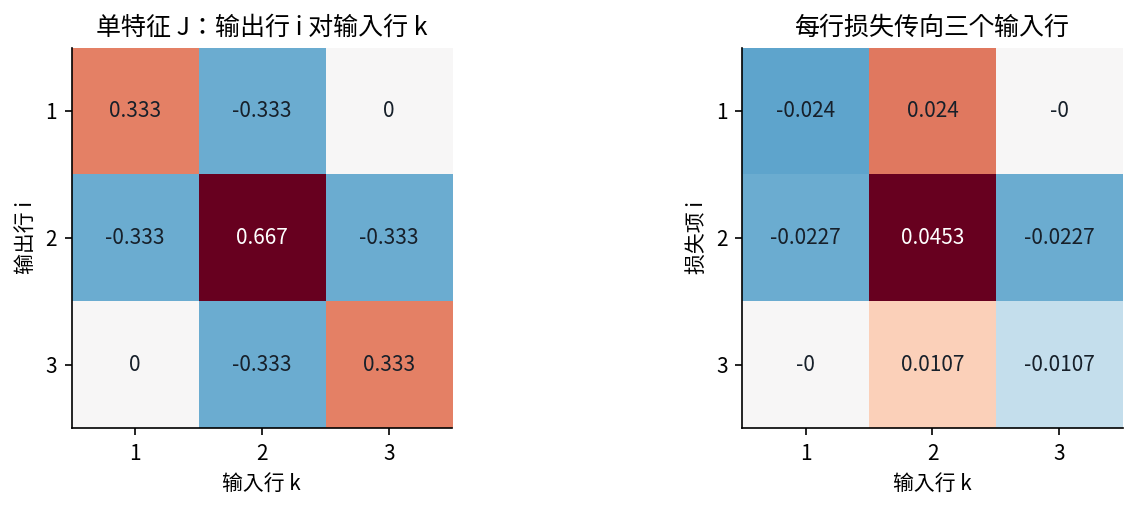

step 1 old [1.0, 0.0, 0.0, 1.0, 1.0, -1.0, 1.0, 0.5, 0.25, -0.1, 0.6, -0.4, 0.05] delta [-0.0013333333333332975, 0.00044444444444444447, -0.001333333333333333, 0.0004444444444444695, 0.0, 0.0, -0.0040000000000000036, 0.002666666666666706, 0.003599999999999992, -0.0023999999999999994, -0.005166666666666653, -0.003933333333333344, 0.006000000000000005] new [0.9986666666666667, 0.00044444444444444447, -0.001333333333333333, 1.0004444444444445, 1.0, -1.0, 0.996, 0.5026666666666667, 0.2536, -0.1024, 0.5948333333333333, -0.40393333333333337, 0.05600000000000001]
step 2 old [0.9986666666666667, 0.00044444444444444447, -0.001333333333333333, 1.0004444444444445, 1.0, -1.0, 0.996, 0.5026666666666667, 0.2536, -0.1024, 0.5948333333333333, -0.40393333333333337, 0.05600000000000001] delta [-0.0011756555997505247, 0.0004000608293526682, -0.00117565559975047, 0.000400060829352622, 0.0, 0.0, -0.003519147936519862, 0.0023925868420171525, 0.0030804927284444616, -0.002091869480711106, -0.00457919594649536

In [4]:
from IPython.display import display, Image
display(Image(filename=str(ROOT / "figures/04_cross_sample.png")))
for s in trace["steps"]:
    print("step", s["step"], "old", s["theta_before"], "delta", s["delta"], "new", s["theta_after"])

In [5]:
second = trace["steps"][1]["forward_backward"]
for key in ["Z", "MU", "VAR", "S", "Q", "H", "P", "residual", "loss", "local", "chain", "contributions", "gradient"]:
    print(key, second[key])
print("third forward", trace["steps"][1]["next_forward"])

Z [[0.0013333333333332975, -1.0004444444444445], [0.9986666666666667, 0.0004444444444444695], [1.996, 1.0013333333333332]]
MU [[0.9986666666666667, 0.0004444444444443955]]
VAR [[0.6631158518518518, 0.667852378600823]]
S [[0.9982230137525308, 1.0005926803320901]]
Q [[-0.9991087358166059, -1.0002960331038004], [0.0, 7.395296780261936e-17], [0.9991087358166058, 1.0002960331038002]]
H [[-0.7415123008733395, -0.605215472640177], [0.2536, -0.10239999999999996], [1.2487123008733394, 0.4004154726401769]]
P [-0.14060953038770257, 0.24821250666666667, 0.637034543721036]
residual [-0.3406095303877026, 0.3482125066666667, -0.16296545627896408]
loss 0.04397075698837094
local {'d_loss_d_p': [-0.1135365101292342, 0.11607083555555557, -0.054321818759654694], 'd_p_d_h': [0.5948333333333333, -0.40393333333333337], 'd_h_d_q': [0.996, 0.5026666666666667], 'd_h_d_gamma': [[-0.9991087358166059, -1.0002960331038004], [0.0, 7.395296780261936e-17], [0.9991087358166058, 1.0002960331038002]], 'd_h_d_beta': [[1.0

In [6]:
print("running states", [s["running_after"] for s in trace["steps"]])
print("eval with saved buffers", trace["eval_after_two_steps"])
print("The pure diagnostic next_forward does not update buffers")

running states [{'mean': [0.2, 0.0], 'variance': [1.0, 1.0], 'num_batches_tracked': 1}, {'mean': [0.35973333333333335, 8.888888888887911e-05], 'variance': [0.9989347555555557, 1.000355713580247], 'num_batches_tracked': 2}]
eval with saved buffers {'P': [0.2523110343257172, 0.5788089774368238, 0.9053069205479304], 'loss': 0.0791012699460568, 'gradient': [0.008965742635198283, -0.003147753533214675, 0.1504708507260379, -0.05282832346304893, 0.14150510809083963, -0.04968056992983425, 0.09991802023623504, -0.006317297530178221, 0.16456815247267878, -0.11359822072295589, 0.2395716478171438, -0.02130242157794254, 0.27880897743682376], 'dX': [[0.00882505250690235, -0.0031319041371152966], [0.1145174234318589, -0.04064084513236671], [0.01776564189859263, -0.006304810913837975]]}
The pure diagnostic next_forward does not update buffers


## 相同shape 不同统计组
BN按N/T归约；LN(D)沿D；LN(T,D)沿末两轴。将框架BN1d的输入显式转成N/D/T。

In [7]:
axes = e.axes_demo()
for key, value in axes.items():
    print(key, value)
if max(axes["torch_max_error"]) > 1e-12:
    raise ArithmeticError("Axis comparison failed")

shape_N_T_D [2, 3, 2]
X [[[0.0, 2.0], [1.0, 4.0], [2.0, 6.0]], [[4.0, -2.0], [5.0, 0.0], [6.0, 2.0]]]
BN_axes_N_T {'mu': [[[3.0, 2.0]]], 'center': [[[-3.0, 0.0], [-2.0, 2.0], [-1.0, 4.0]], [[1.0, -4.0], [2.0, -2.0], [3.0, 0.0]]], 'var': [[[4.666666666666667, 6.666666666666667]]], 's': [[[2.183269719175042, 2.6012817353502227]]], 'q': [[[-1.3740858372430336, 0.0], [-0.916057224828689, 0.7688517444384896], [-0.4580286124143445, 1.5377034888769792]], [[0.4580286124143445, -1.5377034888769792], [0.916057224828689, -0.7688517444384896], [1.3740858372430336, 0.0]]], 'h': [[[-1.3740858372430336, 0.0], [-0.916057224828689, 0.7688517444384896], [-0.4580286124143445, 1.5377034888769792]], [[0.4580286124143445, -1.5377034888769792], [0.916057224828689, -0.7688517444384896], [1.3740858372430336, 0.0]]]}
LN_axes_D {'mu': [[[1.0], [2.5], [4.0]], [[1.0], [2.5], [4.0]]], 'center': [[[-1.0, 1.0], [-1.5, 1.5], [-2.0, 2.0]], [[3.0, -3.0], [2.5, -2.5], [2.0, -2.0]]], 'var': [[[1.0], [2.25], [4.0]], [[9.0]

In [8]:
modes = e.modes_and_buffers()
for key, value in modes.items():
    print(key, value)
print("The mode matrix has gradient tracking and BN buffer updates as separate axes")

untracked_eval {'running_mean_is_none': True, 'train_output': [[-1.0, -1.0], [0.0, 0.0], [1.0, 1.0]], 'eval_output': [[-1.0, -1.0], [0.0, 0.0], [1.0, 1.0]]}
mode_matrix [{'train': True, 'grad_enabled': True, 'output_requires_grad': True, 'running_mean': [0.2, 0.0], 'running_var': [1.0, 1.0], 'batches': 1, 'output': [[-1.0, -1.0], [0.0, 0.0], [1.0, 1.0]]}, {'train': True, 'grad_enabled': False, 'output_requires_grad': False, 'running_mean': [0.2, 0.0], 'running_var': [1.0, 1.0], 'batches': 1, 'output': [[-1.0, -1.0], [0.0, 0.0], [1.0, 1.0]]}, {'train': False, 'grad_enabled': True, 'output_requires_grad': True, 'running_mean': [0.0, 0.0], 'running_var': [1.0, 1.0], 'batches': 0, 'output': [[0.0, -0.8660254037844387], [0.8660254037844387, 0.0], [1.7320508075688774, 0.8660254037844387]]}, {'train': False, 'grad_enabled': False, 'output_requires_grad': False, 'running_mean': [0.0, 0.0], 'running_var': [1.0, 1.0], 'batches': 0, 'output': [[0.0, -0.8660254037844387], [0.8660254037844387, 0.0]

## 微批不是大批BN
两个2行微批正确加权后，统计组仍不同；不要把它当损失归约bug。

In [9]:
print(e.microbatch_example(hand))

{'full_loss': 0.1623673579816456, 'weighted_microbatch_loss': 0.23571551260082124, 'full_gradient': [0.04500041276525299, -0.060449468922375724, -0.1714721982556156, 0.01440157949681089, 1.3877787807814457e-17, 6.938893903907228e-18, 0.21375196063495167, 0.1368150052197036, -0.05100000000000002, 0.03399999999999999, 0.3350032677249195, -0.1625187565246295, -0.08499999999999999], 'weighted_microbatch_gradient': [0.13369580148233215, -0.01853592689719539, -0.2162005779088698, -0.006021161487789372, 0.0, 0.0, 0.23396765259408125, 0.09155882347739117, -0.05100000000000004, 0.034000000000000016, 0.3686960876568021, -0.10594852934673898, -0.08500000000000005], 'max_gradient_gap': 0.08869538871707916, 'note': 'correct weighting cannot undo different normalization groups'}


## 实际重算9份产物
固定锚点4种B×200次；40批统计漂移；六条训练轨迹共480次SGD更新。全部序列化之后才写临时目录。

In [10]:
temporary = tempfile.TemporaryDirectory(prefix="dl036-notebook-")
payloads = e.run()
e.write_payloads(payloads, Path(temporary.name))
for name, content in payloads.items():
    if content != (ROOT / "outputs" / name).read_bytes():
        raise ArithmeticError("Recomputed output differs: " + name)
print("All", len(payloads), "fresh outputs match supplied bytes")

All 9 fresh outputs match supplied bytes


sampling rows 800
peer change {'anchor': [0.5, -0.5], 'BN_before': [0.0, -1.06767312639037], 'BN_after': [-1.3933442853720912, -1.3996227358826583], 'LN_before': [0.998005980069749, -0.998005980069749], 'LN_after': [0.998005980069749, -0.998005980069749]}


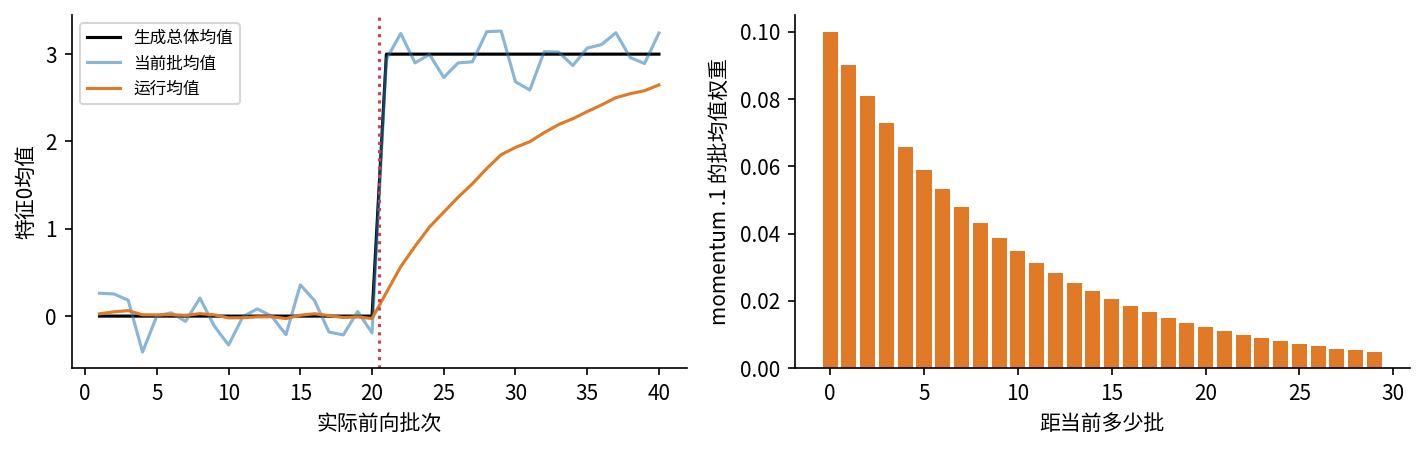

In [11]:
sampling = list(csv.DictReader(io.StringIO(payloads["batch-sampling.csv"].decode())))
print("sampling rows", len(sampling))
sensitivity = json.loads(payloads["batch-sensitivity.json"])
print("peer change", sensitivity["peer_change"])
display(Image(filename=str(ROOT / "figures/07_running_stats.png")))

{'batch_size': '4', 'shuffle_seed': '360', 'optimizer_steps': '128', 'examples': '512', 'eval_half_mse': '0.047943173292711055', 'wrong_train_no_grad_half_mse': '0.1234229914185678', 'eval_after_contamination_half_mse': '0.045309013358698476', 'eval_partition_max_gap': '0.0', 'wrong_prediction_max_gap': '0.8761835259729922', 'num_batches_before': '128', 'num_batches_after_wrong': '136', 'running_mean_max_change': '0.11006187095892067'}
{'batch_size': '4', 'shuffle_seed': '361', 'optimizer_steps': '128', 'examples': '512', 'eval_half_mse': '0.0453843992641354', 'wrong_train_no_grad_half_mse': '0.12834311239907195', 'eval_after_contamination_half_mse': '0.04809961490166869', 'eval_partition_max_gap': '0.0', 'wrong_prediction_max_gap': '0.884672412299182', 'num_batches_before': '128', 'num_batches_after_wrong': '136', 'running_mean_max_change': '0.12448190779920605'}
{'batch_size': '4', 'shuffle_seed': '362', 'optimizer_steps': '128', 'examples': '512', 'eval_half_mse': '0.054599903276100

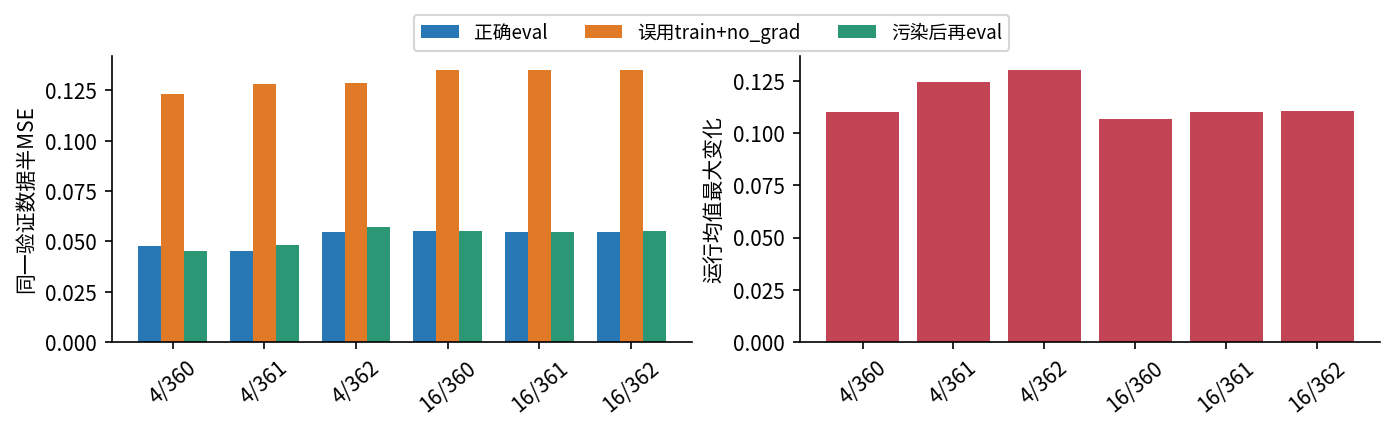

In [12]:
training = list(csv.DictReader(io.StringIO(payloads["training.csv"].decode())))
for row in training:
    print(row)
print("Same512 presentations; B4 has128 updates and B16 has32")
display(Image(filename=str(ROOT / "figures/11_validation_state.png")))

## 独立验证
Fraction、75位Decimal、逐损失自动微分及NumPy完整训练更新为不同检查路线。图显示已冻结文件，数值刚在前格重新计算；独立图重建由make_figures.py完成。

In [13]:
import unittest
import test_experiment
result = unittest.TextTestRunner(verbosity=1).run(unittest.defaultTestLoader.loadTestsFromModule(test_experiment))
if not result.wasSuccessful():
    raise RuntimeError("Reference checks failed")
print("tests", result.testsRun)

.

.

.

.

.

...

.

.

.

----------------------------------------------------------------------
Ran 15 tests in 0.592s

OK


tests 15


## 写下限制
只有合成数据、固定初始化与三种重排；B变化同时改变更新预算与统计更新次数；错误验证的分数更低也不能证明协议正确。

In [14]:
print(json.loads(payloads["summary.json"]))
temporary.cleanup()
print("Completed sequentially without replacing original results")

{'unit': '036', 'runtime': {'torch': '2.7.1+cpu', 'numpy': '2.3.5', 'dtype': 'float64', 'device': 'cpu', 'threads': 1}, 'hand_losses': [0.04513333333333333, 0.04397075698837094, 0.043077682406084096], 'training_runs': 6, 'training_examples_per_run': 512, 'optimizer_steps_by_batch_size': {'4': 128, '16': 32}, 'limits': ['synthetic fixed dataset and initialization', 'three shuffle seeds only', 'equal examples do not mean equal optimizer steps or equal running-stat updates', 'no held-out test ranking or tuning', 'finite CPU checks;no GPU/cross-version guarantee']}
Completed sequentially without replacing original results
